# Liverpool vs Tottenham Hotspur — 2019 UEFA Champions League Final Analysis

## Introduction

This notebook analyzes the 2019 UEFA Champions League Final between Liverpool and Tottenham Hotspur.

The goal is to study the match through basic statistics, xG flow, team behaviour, chance creation, and player-level comparison.

Data will be collected from FBref and used to build a small match analysis project in Python.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Match Information

- Match: Liverpool vs Tottenham Hotspur  
- Competition: UEFA Champions League Final  
- Season: 2018–2019  
- Date: 1 June 2019  
- Stadium: Wanda Metropolitano, Madrid  
- Final Score: Liverpool 2 – 0 Tottenham  
- Data Source: Statsbomb

In [8]:
!pip install statsbombpy

In [9]:
from statsbombpy import sb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [10]:
matches = sb.matches(competition_id=16, season_id=4)
matches.head()

/Users/theightcoder/anaconda3/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,22912,2019-06-01,21:00:00.000,Europe - Champions League,2018/2019,Tottenham Hotspur,Liverpool,0,2,available,scheduled,2022-11-28T14:45:35.628134,2021-06-13T16:17:31.694,13,Final,\tEstádio Cívitas Metropolitano,Damir Skomina,Mauricio Roberto Pochettino Trossero,Jürgen Klopp,1.1.0,2,2


In [11]:
final_match = matches[
    (matches["home_team"] == "Tottenham Hotspur") &
    (matches["away_team"] == "Liverpool")
]

final_match

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,22912,2019-06-01,21:00:00.000,Europe - Champions League,2018/2019,Tottenham Hotspur,Liverpool,0,2,available,scheduled,2022-11-28T14:45:35.628134,2021-06-13T16:17:31.694,13,Final,\tEstádio Cívitas Metropolitano,Damir Skomina,Mauricio Roberto Pochettino Trossero,Jürgen Klopp,1.1.0,2,2


In [12]:
match_id = final_match.iloc[0]["match_id"]
events = sb.events(match_id=match_id)

events.head()

/Users/theightcoder/anaconda3/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_straight,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9ec3d009-c15b-4a8d-be80-57a07f40755a,1,NaN,NaN,22912,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Tottenham Hotspur,38,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Tottenham Hotspur,38,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e8bdb5d1-8bcb-4a0d-bfd2-68c18c7f54d0,2,NaN,NaN,22912,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Tottenham Hotspur,38,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Liverpool,24,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00b678a4-3767-4d0b-92e6-9cb4c959d94d,3,NaN,NaN,22912,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Tottenham Hotspur,38,[05840f64-0fb7-4f2d-885a-49790d6bd4df],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,24,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,05840f64-0fb7-4f2d-885a-49790d6bd4df,4,NaN,NaN,22912,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Tottenham Hotspur,38,[00b678a4-3767-4d0b-92e6-9cb4c959d94d],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tottenham Hotspur,38,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5bf22eb8-1257-4e6f-beca-2a3652936b18,1637,NaN,NaN,22912,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Throw In,NaN,NaN,NaN,81,Tottenham Hotspur,38,[64501101-8a8c-48b0-8184-bd2ac7dad41d],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,24,00:00:00.000,Half Start,NaN


## Match Overview

This section summarizes the basic statistical profile of the match before moving into deeper visual analysis.

In [13]:
# keep only shot events
shots = events[events["type"] == "Shot"].copy()

# select useful columns
shots = shots[[
    "team",
    "player",
    "minute",
    "shot_outcome",
    "shot_statsbomb_xg"
]]

shots.head()

,team,player,minute,shot_outcome,shot_statsbomb_xg
2796,Liverpool,Mohamed Salah,1,Goal,0.783500
2797,Tottenham Hotspur,Moussa Sissoko,9,Off T,0.026189
2798,Liverpool,Trent Alexander-Arnold,16,Off T,0.006203
2799,Liverpool,Mohamed Salah,20,Blocked,0.039799
2800,Liverpool,Mohamed Salah,21,Wayward,0.007078


In [14]:
# create team-level summary stats
match_stats = shots.groupby("team").agg(
    Shots=("team", "count"),
    Goals=("shot_outcome", lambda x: (x == "Goal").sum()),
    xG=("shot_statsbomb_xg", "sum")
).reset_index()

# round xG
match_stats["xG"] = match_stats["xG"].round(2)

match_stats

,team,Shots,Goals,xG
0,Liverpool,14,2,1.20
1,Tottenham Hotspur,16,0,0.92


In [15]:
# add shot conversion
match_stats["Shot_Conversion_%"] = (
    match_stats["Goals"] / match_stats["Shots"] * 100
).round(1)

match_stats

,team,Shots,Goals,xG,Shot_Conversion_%
0,Liverpool,14,2,1.20,14.3
1,Tottenham Hotspur,16,0,0.92,0.0


### xG Flow

This chart shows how expected goals accumulated over time for each team during the match.

In [17]:
# keep only shots
shots_flow = events[events["type"] == "Shot"].copy()

# keep needed columns
shots_flow = shots_flow[["team", "minute", "shot_statsbomb_xg"]]

# sort by time
shots_flow = shots_flow.sort_values("minute")

# cumulative xG per team
shots_flow["cumulative_xg"] = shots_flow.groupby("team")["shot_statsbomb_xg"].cumsum()

shots_flow.head()

,team,minute,shot_statsbomb_xg,cumulative_xg
2796,Liverpool,1,0.783500,0.783500
2797,Tottenham Hotspur,9,0.026189,0.026189
2798,Liverpool,16,0.006203,0.789703
2799,Liverpool,20,0.039799,0.829503
2800,Liverpool,21,0.007078,0.836580


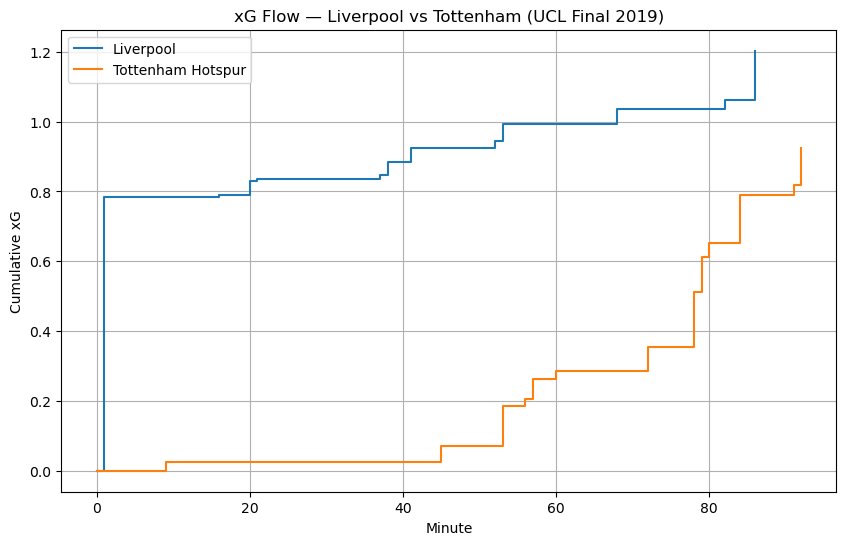

In [19]:
plt.figure(figsize=(10,6))

for team in shots_flow["team"].unique():
    team_data = shots_flow[shots_flow["team"] == team]

    # start at minute 0 with xG = 0
    minutes = [0] + team_data["minute"].tolist()
    xg = [0] + team_data["cumulative_xg"].tolist()

    plt.step(minutes, xg, where="post", label=team)

plt.xlabel("Minute")
plt.ylabel("Cumulative xG")
plt.title("xG Flow — Liverpool vs Tottenham (UCL Final 2019)")
plt.legend()
plt.grid(True)

plt.show()

## Team Behaviour

This section examines how Liverpool moved the ball during the match through passing structure and spatial activity.

In [21]:
# keep only passes
passes = events[events["type"] == "Pass"].copy()

# keep only completed passes
passes = passes[passes["pass_outcome"].isna()]

# keep Liverpool passes
liverpool_passes = passes[passes["team"] == "Liverpool"].copy()

liverpool_passes.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_straight,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.666205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b67ef6a9-e877-4dbe-bb03-edcc9d8c7711,5,NaN,"[61.0, 40.1]",22912,0,NaN,NaN,NaN,3.005404,NaN,Right Foot,NaN,NaN,NaN,"[34.0, 43.8]",NaN,Ground Pass,NaN,27.252338,NaN,NaN,Joël Andre Job Matip,3502.0,NaN,NaN,NaN,NaN,NaN,Kick Off,1,From Kick Off,Jordan Brian Henderson,3532.0,Right Center Midfield,2,Liverpool,24,[c7297515-ae92-4fb4-93a8-59745b8dfa90],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,24,00:00:00.208,Pass,NaN
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.067295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3b52ec7a-0b60-480a-8673-475fce779342,21,NaN,"[59.5, 19.6]",22912,0,NaN,NaN,NaN,-0.067693,NaN,Head,NaN,NaN,NaN,"[65.4, 19.2]",NaN,Low Pass,NaN,5.913544,NaN,NaN,Georginio Wijnaldum,3567.0,NaN,NaN,NaN,NaN,NaN,Recovery,1,From Kick Off,Virgil van Dijk,3669.0,Left Center Back,2,Liverpool,24,"[66785f3c-c999-4474-8f7f-5d09b11e64e1, bdead4f...",14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,24,00:00:14.904,Pass,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.733968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0be6b52c-a97a-40fd-aa49-ec977ed51727,25,NaN,"[64.7, 18.4]",22912,0,NaN,NaN,NaN,1.533776,NaN,Right Foot,NaN,NaN,NaN,"[64.9, 23.8]",NaN,Low Pass,NaN,5.403702,NaN,NaN,Jordan Brian Henderson,3532.0,NaN,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Georginio Wijnaldum,3567.0,Left Center Midfield,2,Liverpool,24,"[bc978401-3bdf-4d44-ac03-a0081664fd4e, df4587a...",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,24,00:00:16.045,Pass,True
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.502852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58da02c1-4fc2-45ee-a8ae-7b40bdb01238,28,NaN,"[64.3, 24.3]",22912,0,NaN,NaN,NaN,0.005731,NaN,Right Foot,NaN,NaN,NaN,"[99.2, 24.5]",NaN,High Pass,NaN,34.900574,NaN,NaN,Sadio Mané,3629.0,NaN,NaN,NaN,Through Ball,True,NaN,1,From Kick Off,Jordan Brian Henderson,3532.0,Right Center Midfield,2,Liverpool,24,[0db11b7a-2581-4f5e-a2d4-53b1c10a72b3],17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,24,00:00:17.057,Pass,NaN
28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.545644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bb75248f-a6dd-4ade-8c6d-05301df5efa9,66,NaN,"[43.7, 0.1]",22912,3,NaN,NaN,NaN,0.703614,NaN,NaN,NaN,NaN,NaN,"[53.6, 8.5]",NaN,High Pass,NaN,12.983451

In [22]:
# extract pass start locations
liverpool_passes["x"] = liverpool_passes["location"].apply(lambda x: x[0])
liverpool_passes["y"] = liverpool_passes["location"].apply(lambda x: x[1])

# extract pass end locations
liverpool_passes["end_x"] = liverpool_passes["pass_end_location"].apply(lambda x: x[0])
liverpool_passes["end_y"] = liverpool_passes["pass_end_location"].apply(lambda x: x[1])

liverpool_passes[["player","x","y","end_x","end_y"]].head()

,player,x,y,end_x,end_y
6,Jordan Brian Henderson,61.0,40.1,34.0,43.8
13,Virgil van Dijk,59.5,19.6,65.4,19.2
14,Georginio Wijnaldum,64.7,18.4,64.9,23.8
15,Jordan Brian Henderson,64.3,24.3,99.2,24.5
28,Andrew Robertson,43.7,0.1,53.6,8.5


### Liverpool Passing Heatmap
This heatmap shows where Liverpool completed passes during the match, highlighting the areas where the team circulated the ball most frequently.

In [24]:
# check pitch coordinate ranges
print(liverpool_passes["x"].min(), liverpool_passes["x"].max())
print(liverpool_passes["y"].min(), liverpool_passes["y"].max())

3.0 120.0
0.1 80.0


In [25]:
!pip install mplsoccer

### Liverpool Passing Heatmap
This heatmap shows where Liverpool completed passes during the match, highlighting the zones where the team circulated the ball most frequently.

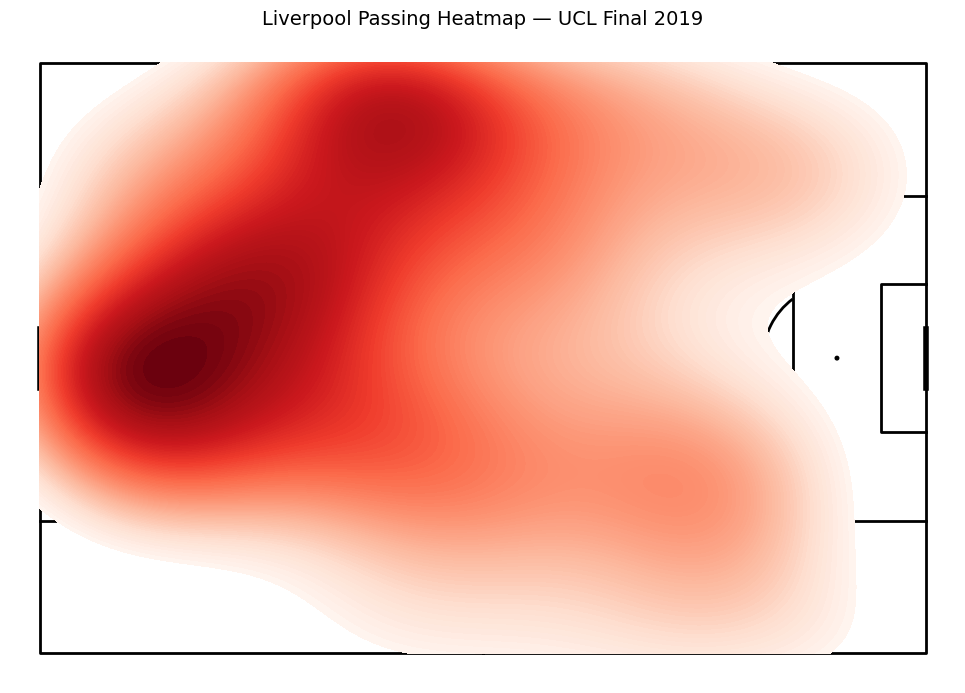

In [27]:
from mplsoccer import Pitch

pitch = Pitch(pitch_type="statsbomb", pitch_color="white", line_color="black")

fig, ax = pitch.draw(figsize=(10,7))

# heatmap of pass locations
pitch.kdeplot(
    liverpool_passes["x"],
    liverpool_passes["y"],
    ax=ax,
    fill=True,
    levels=100,
    cmap="Reds"
)

plt.title("Liverpool Passing Heatmap — UCL Final 2019", fontsize=14)

plt.show()

In [28]:
# Liverpool shots only
liverpool_shots = events[
    (events["type"] == "Shot") &
    (events["team"] == "Liverpool")
].copy()

# extract shot locations
liverpool_shots["x"] = liverpool_shots["location"].apply(lambda loc: loc[0])
liverpool_shots["y"] = liverpool_shots["location"].apply(lambda loc: loc[1])

# goal flag
liverpool_shots["is_goal"] = liverpool_shots["shot_outcome"] == "Goal"

liverpool_shots[["player", "minute", "x", "y", "shot_statsbomb_xg", "shot_outcome", "is_goal"]].head()

,player,minute,x,y,shot_statsbomb_xg,shot_outcome,is_goal
2796,Mohamed Salah,1,108.2,40.1,0.783500,Goal,True
2798,Trent Alexander-Arnold,16,90.2,59.3,0.006203,Off T,False
2799,Mohamed Salah,20,95.2,47.2,0.039799,Blocked,False
2800,Mohamed Salah,21,113.0,59.5,0.007078,Wayward,False
2801,Andrew Robertson,37,98.4,20.4,0.009163,Saved,False


## Chance Creation

This section focuses on where Liverpool created shots and how dangerous those chances were.

### Liverpool Shot Map
This shot map shows Liverpool's shot locations in the final, with marker size representing xG and goals highlighted in green.

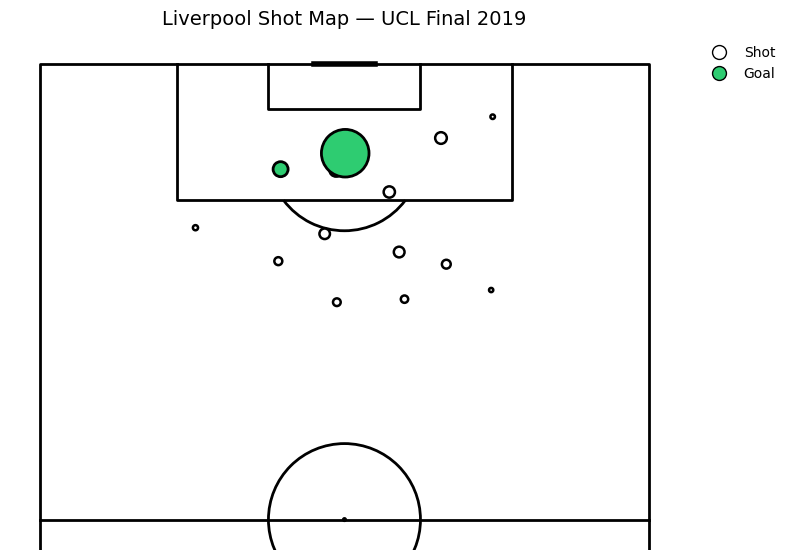

In [34]:
from mplsoccer import VerticalPitch
from matplotlib.lines import Line2D

pitch = VerticalPitch(
    pitch_type="statsbomb",
    half=True,
    pitch_color="white",
    line_color="black"
)

fig, ax = pitch.draw(figsize=(8, 10))

# non-goal shots
non_goals = liverpool_shots[liverpool_shots["is_goal"] == False]
pitch.scatter(
    non_goals["x"],
    non_goals["y"],
    s=non_goals["shot_statsbomb_xg"] * 1500,
    color="white",
    edgecolors="black",
    linewidth=1.8,
    ax=ax
)

# goals
goals = liverpool_shots[liverpool_shots["is_goal"] == True]
pitch.scatter(
    goals["x"],
    goals["y"],
    s=goals["shot_statsbomb_xg"] * 1500,
    color="#2ecc71",
    edgecolors="black",
    linewidth=2,
    ax=ax
)

# legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Shot',
           markerfacecolor='white', markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Goal',
           markerfacecolor='#2ecc71', markeredgecolor='black', markersize=10)
]

ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.title("Liverpool Shot Map — UCL Final 2019", fontsize=14)
plt.show()

**Observation**

Liverpool created most of their shots from central areas around the edge of the box and inside the penalty area.  
The highest-quality chance (largest circle) resulted in Mohamed Salah’s early penalty goal, while most other attempts came from lower-probability positions outside the central danger zone.

### Liverpool Pass Network
This pass network shows Liverpool's average player positions and the strongest passing connections during the match.

In [35]:
# keep only the columns we need
network_passes = liverpool_passes[[
    "player",
    "pass_recipient",
    "x",
    "y"
]].copy()

# remove rows without recipient
network_passes = network_passes.dropna(subset=["pass_recipient"])

# average position of each passer
avg_positions = network_passes.groupby("player").agg(
    avg_x=("x", "mean"),
    avg_y=("y", "mean"),
    pass_count=("player", "count")
).reset_index()

# passing connections between players
pass_connections = network_passes.groupby(
    ["player", "pass_recipient"]
).size().reset_index(name="pass_count")

avg_positions.head(), pass_connections.head()

(                   player      avg_x      avg_y  pass_count
 0   Alisson Ramsés Becker  10.668000  41.760000          25
 1        Andrew Robertson  51.720588   8.402941          34
 2      Divock Okoth Origi  65.250000  33.025000           4
 3  Fábio Henrique Tavares  51.921429  41.750000          14
 4     Georginio Wijnaldum  73.550000  30.725000          12,
                   player          pass_recipient  pass_count
 0  Alisson Ramsés Becker        Andrew Robertson           6
 1  Alisson Ramsés Becker  Fábio Henrique Tavares           3
 2  Alisson Ramsés Becker     James Philip Milner           2
 3  Alisson Ramsés Becker    Joël Andre Job Matip           3
 4  Alisson Ramsés Becker           Mohamed Salah           1)

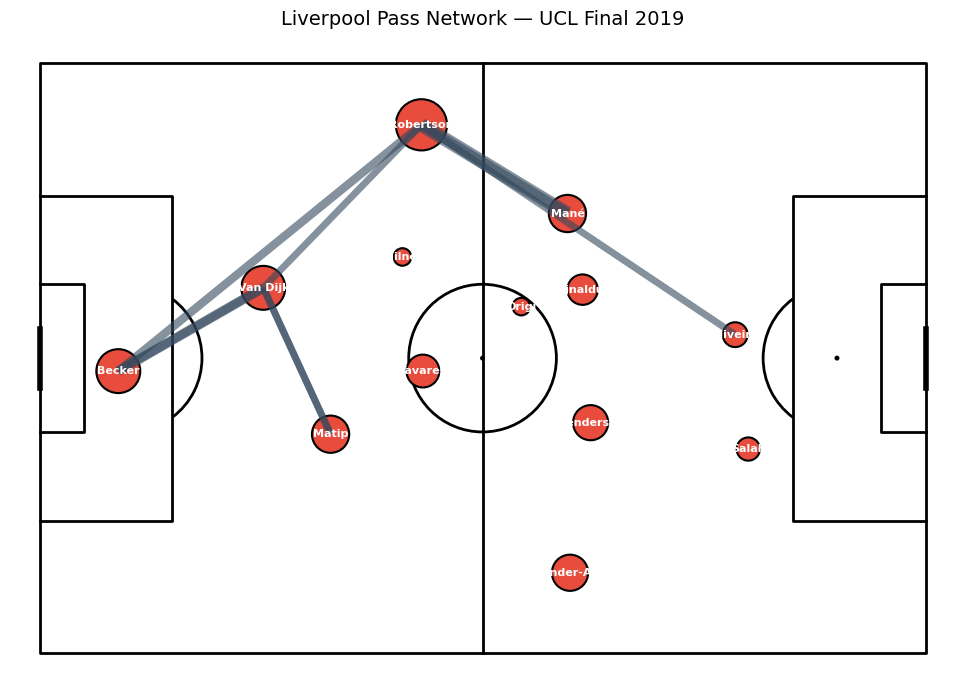

In [39]:
from mplsoccer import Pitch

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="white",
    line_color="black"
)

fig, ax = pitch.draw(figsize=(10,7))

# draw player nodes
pitch.scatter(
    avg_positions["avg_x"],
    avg_positions["avg_y"],
    s=avg_positions["pass_count"] * 40,
    color="#e74c3c",
    edgecolors="black",
    linewidth=1.5,
    ax=ax
)

# draw player labels
for i, row in avg_positions.iterrows():
    name = row["player"].split()[-1]

    if name == "Dijk":
        name = "Van Dijk"

    ax.text(
        row["avg_x"],
        row["avg_y"],
        name,
        ha="center",
        va="center",
        fontsize=8,
        color="white",
        weight="bold"
    )

# draw pass connections
for _, row in pass_connections.iterrows():
    
    passer = row["player"]
    receiver = row["pass_recipient"]
    count = row["pass_count"]
    
    if count < 5:
        continue
    
    start = avg_positions[avg_positions["player"] == passer]
    end = avg_positions[avg_positions["player"] == receiver]
    
    if len(start) == 0 or len(end) == 0:
        continue
    
    x1 = start["avg_x"].values[0]
    y1 = start["avg_y"].values[0]
    x2 = end["avg_x"].values[0]
    y2 = end["avg_y"].values[0]
    
    pitch.lines(
        x1, y1, x2, y2,
        lw=count,
        color="#34495e",
        alpha=0.6,
        ax=ax
    )

plt.title("Liverpool Pass Network — UCL Final 2019", fontsize=14)
plt.show()

## Player Comparison

This section compares one Liverpool player's match performance using key attacking metrics.

In [40]:
player_match_stats = events.groupby("player").agg(
    shots=("type", lambda x: (x == "Shot").sum()),
    passes=("type", lambda x: (x == "Pass").sum()),
    carries=("type", lambda x: (x == "Carry").sum())
).reset_index()

player_match_stats = player_match_stats[player_match_stats["player"].notna()]
player_match_stats = player_match_stats.sort_values("shots", ascending=False)

player_match_stats.head(15)

,player,shots,passes,carries
21,Mohamed Salah,6,17,19
12,Heung-Min Son,3,26,29
2,Bamidele Alli,3,36,33
3,Christian Dannemann Eriksen,3,45,45
4,Danny Rose,2,49,39
20,Lucas Rodrigues Moura da Silva,2,5,10
17,Jordan Brian Henderson,2,26,20
14,James Philip Milner,1,7,5
26,Trent Alexander-Arnold,1,47,17
22,Moussa Sissoko,1,34,31


In [41]:
players_compare = player_match_stats[
    player_match_stats["player"].isin(["Mohamed Salah", "Heung-Min Son"])
]

players_compare

,player,shots,passes,carries
21,Mohamed Salah,6,17,19
12,Heung-Min Son,3,26,29


In [44]:
players_compare = players_compare.merge(player_xg, on="player", how="left")
players_compare["xg"] = players_compare["xg"].fillna(0)

players_compare

,player,shots,passes,carries,xg
0,Mohamed Salah,6,17,19,0.937533
1,Heung-Min Son,3,26,29,0.123909


In [45]:
player_xg = events[events["type"] == "Shot"].groupby("player").agg(
    xg=("shot_statsbomb_xg", "sum")
).reset_index()

player_xg

,player,xg
0,Andrew Robertson,0.009163
1,Bamidele Alli,0.338535
2,Christian Dannemann Eriksen,0.076393
3,Danny Rose,0.047833
4,Divock Okoth Origi,0.077973
5,Fábio Henrique Tavares,0.020488
6,Harry Kane,0.050692
7,Heung-Min Son,0.123909
8,James Philip Milner,0.044092
9,Jan Vertonghen,0.057149


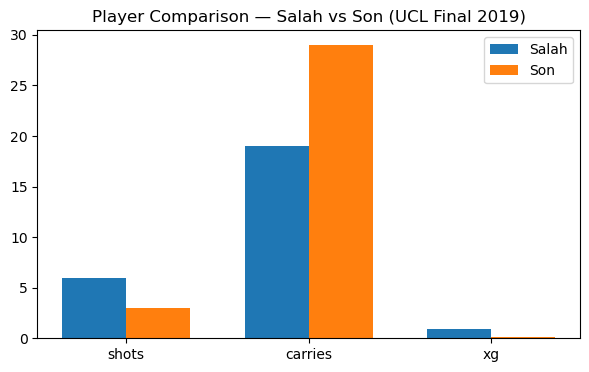

In [46]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["shots", "carries", "xg"]

salah = players_compare[players_compare["player"] == "Mohamed Salah"][metrics].values[0]
son = players_compare[players_compare["player"] == "Heung-Min Son"][metrics].values[0]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7,4))

ax.bar(x - width/2, salah, width, label="Salah")
ax.bar(x + width/2, son, width, label="Son")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title("Player Comparison — Salah vs Son (UCL Final 2019)")
ax.legend()

plt.show()

### Conclusion

Liverpool generated higher-quality chances, reflected in Mohamed Salah's higher shot count and xG. 
Tottenham relied more on ball progression through carries, particularly from Heung-Min Son, but this did not translate into high-quality scoring opportunities. 

Overall, Liverpool’s attacking structure produced more dangerous shots, which aligns with their 2–0 victory in the final.